In [4]:
# Cell 1 — Imports and constants
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

# Paths
PROCESSED_DIR = Path("../data/processed/anti_uav_v4")

# All sequence directories, sorted
seq_dirs = sorted([d for d in PROCESSED_DIR.iterdir() if d.is_dir()])

print(f"Sequences found: {len(seq_dirs)}")

Sequences found: 200


In [5]:
# Cell 2 — Collect statistics across all sequences
boxes_per_frame = []   # how many UAVs in each frame
box_widths      = []   # normalized widths of all boxes
box_heights     = []   # normalized heights of all boxes
box_areas       = []   # normalized area (w * h) of all boxes
empty_frames    = 0    # frames with zero UAVs

for seq_dir in seq_dirs:
    for label_path in sorted(seq_dir.glob("*.txt")):
        text = label_path.read_text().strip()

        if not text:
            boxes_per_frame.append(0)
            empty_frames += 1
            continue

        lines = text.splitlines()
        boxes_per_frame.append(len(lines))

        for line in lines:
            parts = line.split()
            w = float(parts[3])
            h = float(parts[4])
            box_widths.append(w)
            box_heights.append(h)
            box_areas.append(w * h)

total_frames = len(boxes_per_frame)
total_boxes  = len(box_widths)

print(f"Total frames         : {total_frames:,}")
print(f"Total annotations    : {total_boxes:,}")
print(f"Empty frames         : {empty_frames:,}  ({100*empty_frames/total_frames:.1f}%)")
print(f"Avg UAVs/frame       : {np.mean(boxes_per_frame):.2f}")
print(f"Max UAVs/frame       : {np.max(boxes_per_frame)}")
print(f"Avg box width        : {np.mean(box_widths):.4f}  ({np.mean(box_widths)*640:.1f}px)")
print(f"Avg box height       : {np.mean(box_heights):.4f}  ({np.mean(box_heights)*512:.1f}px)")
print(f"Avg box area (norm)  : {np.mean(box_areas):.6f}")

Total frames         : 151,773
Total annotations    : 3,142,045
Empty frames         : 81  (0.1%)
Avg UAVs/frame       : 20.70
Max UAVs/frame       : 53
Avg box width        : 0.0165  (10.6px)
Avg box height       : 0.0177  (9.1px)
Avg box area (norm)  : 0.000364


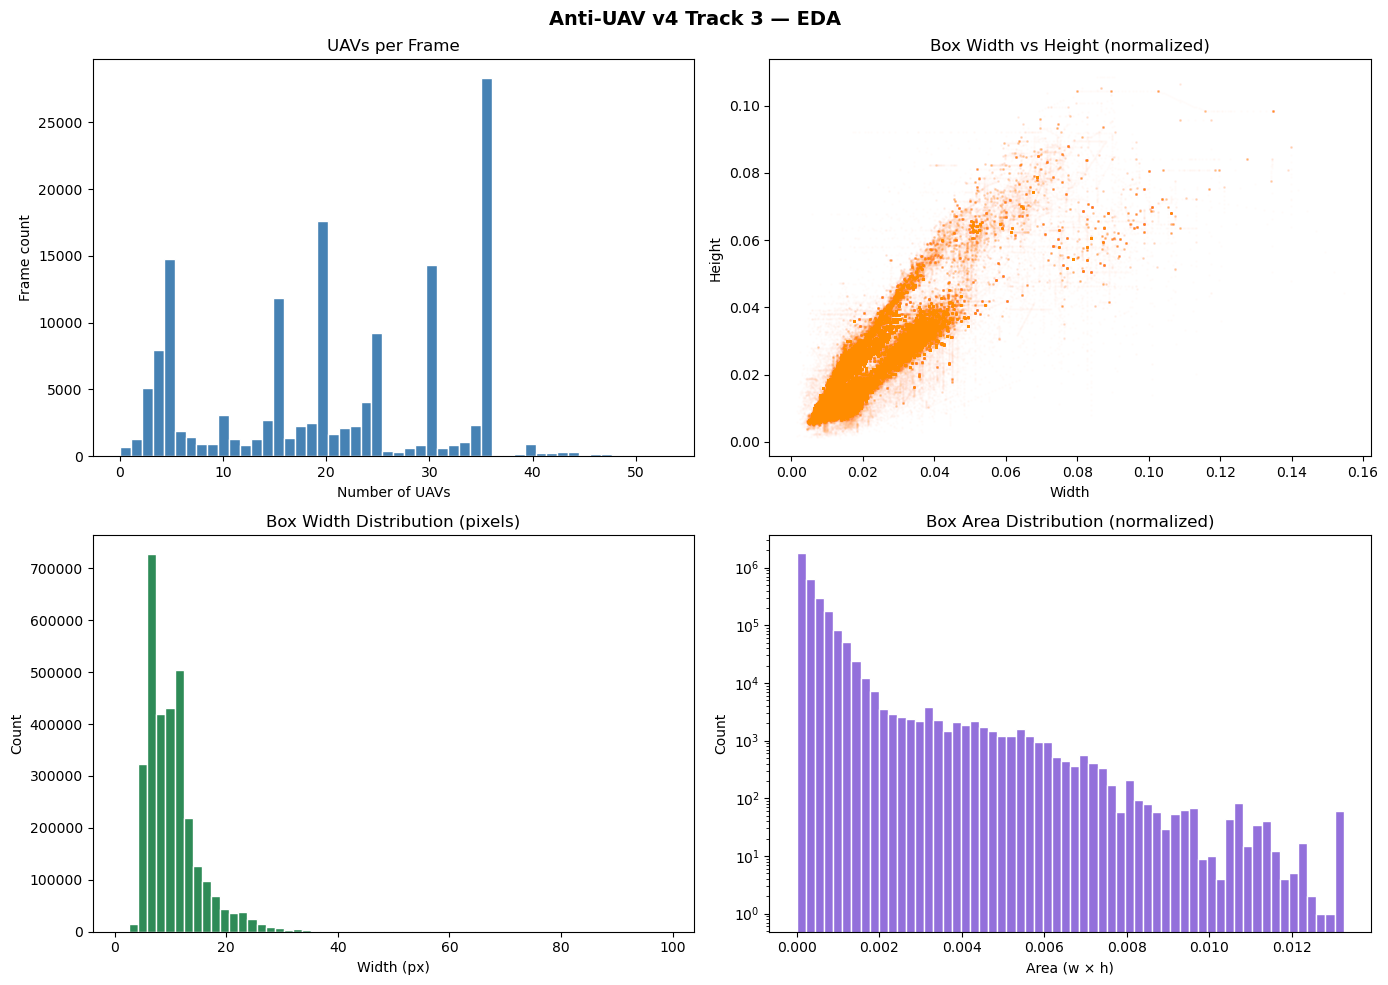

Plot saved.


In [6]:
# Cell 3 — Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Anti-UAV v4 Track 3 — EDA", fontsize=14, fontweight="bold")

# Plot 1 — Distribution of UAVs per frame
axes[0, 0].hist(boxes_per_frame, bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("UAVs per Frame")
axes[0, 0].set_xlabel("Number of UAVs")
axes[0, 0].set_ylabel("Frame count")

# Plot 2 — Box width vs height scatter (normalized)
axes[0, 1].scatter(box_widths, box_heights, alpha=0.01, s=1, color="darkorange")
axes[0, 1].set_title("Box Width vs Height (normalized)")
axes[0, 1].set_xlabel("Width")
axes[0, 1].set_ylabel("Height")

# Plot 3 — Box width distribution in pixels
axes[1, 0].hist([w * 640 for w in box_widths], bins=60, color="seagreen", edgecolor="white")
axes[1, 0].set_title("Box Width Distribution (pixels)")
axes[1, 0].set_xlabel("Width (px)")
axes[1, 0].set_ylabel("Count")

# Plot 4 — Box area distribution (normalized, log scale)
axes[1, 1].hist(box_areas, bins=60, color="mediumpurple", edgecolor="white")
axes[1, 1].set_title("Box Area Distribution (normalized)")
axes[1, 1].set_xlabel("Area (w × h)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.savefig("../notebooks/eda_anti_uav_v4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")